# Cost-sensitive evaluation (baseline vs diffusion-augmented)

This notebook is where we connect the whole pipeline to the **real objective**:

> Minimize maintenance decision cost, where missing a real APS failure is much more expensive than a false alarm.

We evaluate:
1. A baseline model trained on the original training data
2. A model trained on a **diffusion-augmented** training dataset (synthetic failures added)

---

## Inputs

Expected (PCA space):
- `../../data/processed/pca_aps_mean_failure_train_set.csv`
- `../../data/processed/pca_aps_mean_failure_test_set.csv`

Optional (produced by diffusion notebook):
- `../../outputs/tables/diffusion_synth_failure_pca_<RUN_ID>.csv`

---

## Outputs

- Cost, confusion matrix, precision/recall/F1
- Validation-tuned threshold and LR regularization
- A comparison summary: tuned baseline vs tuned diffusion-augmented LR


## 0) Imports + helper functions

In [1]:
from pathlib import Path
import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)
import matplotlib.pyplot as plt


### Define the cost function

From the APS case study, we treat:
- **False Positive (FP)**: unnecessary check (cost 10)
- **False Negative (FN)**: missed real failure (cost 500)

Cost = 10 * FP + 500 * FN


In [2]:
CFP = 10   # cost of false positive
CFN = 500  # cost of false negative
RANDOM_STATE = 42
THRESHOLD_GRID = np.linspace(0.01, 0.99, 99)
LR_C_GRID = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
TARGET_MINORITY_TOTALS = [1200, 1600, 2400, 4000]

def cost_from_confusion(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return CFP * fp + CFN * fn, {"tn": tn, "fp": fp, "fn": fn, "tp": tp}

def metrics_summary(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cost, cm = cost_from_confusion(y_true, y_pred)
    return {
        "threshold": float(threshold),
        "cost": float(cost),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        **cm
    }

def tune_lr_on_dataframe(df, pc_cols, X_test, y_test, name, c_grid=LR_C_GRID, threshold_grid=THRESHOLD_GRID):
    X_all = df[pc_cols].values
    y_all = df["class"].values.astype(int)

    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    (train_idx, val_idx), = sss.split(X_all, y_all)
    X_train, y_train = X_all[train_idx], y_all[train_idx]
    X_val, y_val = X_all[val_idx], y_all[val_idx]

    tuning_rows = []
    best = None

    for C in c_grid:
        clf = LogisticRegression(max_iter=4000, class_weight="balanced", C=C)
        clf.fit(X_train, y_train)

        val_prob = clf.predict_proba(X_val)[:, 1]
        test_prob = clf.predict_proba(X_test)[:, 1]

        costs = []
        for th in threshold_grid:
            y_pred = (val_prob >= th).astype(int)
            cost, _ = cost_from_confusion(y_val, y_pred)
            costs.append(cost)

        best_i = int(np.argmin(costs))
        best_th = float(threshold_grid[best_i])
        val_best_cost = float(costs[best_i])

        row = {
            "name": name,
            "C": float(C),
            "threshold": best_th,
            "val_best_cost": val_best_cost,
        }
        tuning_rows.append(row)

        if best is None or val_best_cost < best["val_best_cost"]:
            best = {
                **row,
                "test_prob": test_prob,
                "val_cost_curve": costs,
            }

    result = metrics_summary(y_test, best["test_prob"], threshold=best["threshold"])
    result.update({
        "name": name,
        "C": best["C"],
        "val_best_cost": best["val_best_cost"],
    })
    tuning_df = pd.DataFrame(tuning_rows).sort_values(["val_best_cost", "C"]).reset_index(drop=True)
    return result, tuning_df, best

def build_diffusion_augmented_df(train_df, synth_df, target_minority_total):
    current_minority = int((train_df["class"] == 1).sum())
    n_to_add = max(0, target_minority_total - current_minority)
    n_to_add = min(n_to_add, len(synth_df))
    sampled = synth_df.sample(n=n_to_add, random_state=RANDOM_STATE).reset_index(drop=True)
    return pd.concat([train_df, sampled], ignore_index=True)


## 1) Load PCA train/test

If these files are missing, run the preprocessing notebook first:
- `01_DataExploration_Preprocessing_TUTORIAL.ipynb`


In [3]:
train_path = Path("../../data/processed/pca_aps_mean_failure_train_set.csv")
test_path  = Path("../../data/processed/pca_aps_mean_failure_test_set.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError(
        "Missing PCA files. Expected ../../data/processed/pca_aps_mean_failure_train_set.csv and ../../data/processed/pca_aps_mean_failure_test_set.csv. "
        "Run the preprocessing notebook to generate them."
    )

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

pc_cols = [c for c in train_df.columns if c.startswith("pc_")]
X = train_df[pc_cols].values
y = train_df["class"].values.astype(int)

X_test = test_df[pc_cols].values
y_test = test_df["class"].values.astype(int)

print("Train shape:", train_df.shape, "Test shape:", test_df.shape)
print("Train class counts:", pd.Series(y).value_counts().to_dict())
print("Test  class counts:", pd.Series(y_test).value_counts().to_dict())


Train shape: (60000, 12) Test shape: (16000, 12)
Train class counts: {0: 59000, 1: 1000}
Test  class counts: {0: 15625, 1: 375}


## 2) Tune the baseline logistic regression fairly

We tune LR regularization (`C`) and the decision threshold on a validation split, then evaluate once on the test set.


In [4]:
baseline_test, baseline_tuning, baseline_best = tune_lr_on_dataframe(
    train_df,
    pc_cols,
    X_test,
    y_test,
    name="plain_lr_baseline",
)

baseline_tuning


,name,C,threshold,val_best_cost
0,plain_lr_baseline,2.00,0.46,9760.0
1,plain_lr_baseline,1.00,0.46,9770.0
2,plain_lr_baseline,0.50,0.45,9900.0
3,plain_lr_baseline,0.20,0.49,10400.0
4,plain_lr_baseline,0.10,0.51,10640.0
5,plain_lr_baseline,0.05,0.50,10750.0
6,plain_lr_baseline,0.02,0.42,11110.0


## 3) Baseline result

This is the best baseline configuration selected only by validation cost.


In [5]:
baseline_test


{'threshold': 0.46,
 'cost': 17530.0,
 'precision': 0.3203971119133574,
 'recall': 0.9466666666666667,
 'f1': 0.4787592717464599,
 'roc_auc': 0.9783232,
 'pr_auc': 0.5756643628727472,
 'tn': np.int64(14872),
 'fp': np.int64(753),
 'fn': np.int64(20),
 'tp': np.int64(355),
 'name': 'plain_lr_baseline',
 'C': 2.0,
 'val_best_cost': 9760.0}

## 4) Baseline validation curve

We plot the validation-cost curve for the baseline configuration that won the fair tuning pass.


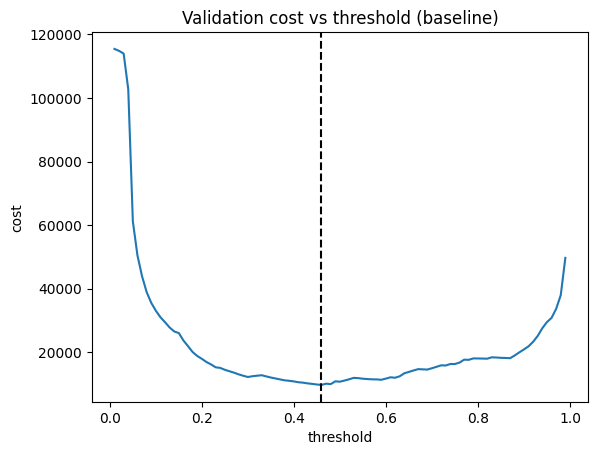

In [6]:
plt.figure()
plt.plot(THRESHOLD_GRID, baseline_best["val_cost_curve"])
plt.axvline(baseline_test["threshold"], linestyle="--", color="black")
plt.title("Validation cost vs threshold (baseline)")
plt.xlabel("threshold")
plt.ylabel("cost")
plt.show()


## 5) Tune diffusion-augmented logistic regression fairly

In [7]:
synth_candidates = sorted(glob.glob("../../outputs/tables/diffusion_synth_failure_pca_*.csv"))
if not synth_candidates:
    raise FileNotFoundError(
        "No synthetic pool found. Run the diffusion notebook to generate ../../outputs/tables/diffusion_synth_failure_pca_<RUN_ID>.csv first."
    )

synth_path = Path(synth_candidates[-1])
print("Using synthetic pool:", synth_path)

synth_df = pd.read_csv(synth_path)
current_minority = int((train_df["class"] == 1).sum())
candidate_targets = [t for t in TARGET_MINORITY_TOTALS if t > current_minority]

diffusion_results = []
diffusion_tuning_tables = {}
diffusion_best = None

for target in candidate_targets:
    aug_df = build_diffusion_augmented_df(train_df, synth_df, target)
    result, tuning_df, best_cfg = tune_lr_on_dataframe(
        aug_df,
        pc_cols,
        X_test,
        y_test,
        name=f"diffusion_augmented_lr_target{target}",
    )
    result["target_minority_total"] = int(target)
    diffusion_results.append(result)
    diffusion_tuning_tables[target] = tuning_df
    if diffusion_best is None or result["val_best_cost"] < diffusion_best["val_best_cost"]:
        diffusion_best = result

pd.DataFrame(diffusion_results).sort_values("val_best_cost").reset_index(drop=True)


Using synthetic pool: ../../outputs/tables/diffusion_synth_failure_pca_20260319_170730.csv


,threshold,cost,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp,name,C,val_best_cost,target_minority_total
0,0.49,19680.0,0.343166,0.930667,0.501437,0.978238,0.577456,14957,668,26,349,diffusion_augmented_lr_target1200,0.20,11640.0,1200
1,0.33,17180.0,0.261784,0.962667,0.411631,0.976890,0.578684,14607,1018,14,361,diffusion_augmented_lr_target1600,0.05,12120.0,1600
2,0.34,17050.0,0.264275,0.962667,0.414704,0.977043,0.578768,14620,1005,14,361,diffusion_augmented_lr_target2400,0.20,13220.0,2400
3,0.27,17200.0,0.244774,0.968000,0.390743,0.977375,0.578376,14505,1120,12,363,diffusion_augmented_lr_target4000,0.50,15780.0,4000


## 6) Best diffusion result

This is the best diffusion-augmented LR configuration selected only by validation cost.


In [8]:
diffusion_best


{'threshold': 0.49,
 'cost': 19680.0,
 'precision': 0.34316617502458213,
 'recall': 0.9306666666666666,
 'f1': 0.5014367816091954,
 'roc_auc': 0.9782384639999998,
 'pr_auc': 0.577455571365255,
 'tn': np.int64(14957),
 'fp': np.int64(668),
 'fn': np.int64(26),
 'tp': np.int64(349),
 'name': 'diffusion_augmented_lr_target1200',
 'C': 0.2,
 'val_best_cost': 11640.0,
 'target_minority_total': 1200}

## 7) Compare tuned baseline vs tuned diffusion-augmented LR

This is the fair headline comparison: both sides get LR hyperparameter tuning and threshold tuning on validation only.


In [9]:
comparison = pd.DataFrame([
    baseline_test,
    diffusion_best,
]).set_index("name")

comparison = comparison[[
    "C", "threshold", "val_best_cost", "cost", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"
]]

tables_dir = Path("../../outputs/tables")
figures_dir = Path("../../outputs/figures")
tables_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
comparison.reset_index().to_csv(tables_dir / "experiment_results.csv", index=False)

comparison


,C,threshold,val_best_cost,cost,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
name,,,,,,,,,,,,,
plain_lr_baseline,2.0,0.46,9760.0,17530.0,0.320397,0.946667,0.478759,0.978323,0.575664,14872,753,20,355
diffusion_augmented_lr_target1200,0.2,0.49,11640.0,19680.0,0.343166,0.930667,0.501437,0.978238,0.577456,14957,668,26,349


## 8) Illustrative demo comparison (explicitly not a fair benchmark)

If the goal is a classroom or workshop demo, it can be useful to show a **simple untuned baseline** against the **best diffusion-augmented configuration**.

This is intentionally illustrative:
- baseline = plain logistic regression on the original imbalanced training set
- threshold fixed at `0.5`
- no cost-based tuning for the baseline
- diffusion side uses the validation-tuned configuration found above

Use this section only as a demo slide / teaching artifact, not as a benchmark claim.


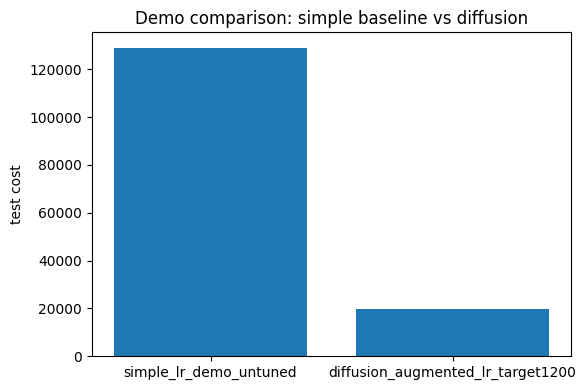

,C,threshold,val_best_cost,cost,precision,recall,f1,roc_auc,pr_auc,tn,fp,fn,tp
name,,,,,,,,,,,,,
simple_lr_demo_untuned,1.0,0.50,NaN,129030.0,0.690058,0.314667,0.432234,0.971753,0.581155,15572,53,257,118
diffusion_augmented_lr_target1200,0.2,0.49,11640.0,19680.0,0.343166,0.930667,0.501437,0.978238,0.577456,14957,668,26,349


In [10]:
simple_demo_clf = LogisticRegression(max_iter=4000, C=1.0)
simple_demo_clf.fit(X, y)
simple_demo_prob = simple_demo_clf.predict_proba(X_test)[:, 1]

simple_baseline_demo = metrics_summary(y_test, simple_demo_prob, threshold=0.5)
simple_baseline_demo.update({
    "name": "simple_lr_demo_untuned",
    "C": 1.0,
    "val_best_cost": np.nan,
})

demo_comparison = pd.DataFrame([
    simple_baseline_demo,
    diffusion_best,
]).set_index("name")

demo_comparison = demo_comparison[[
    "C", "threshold", "val_best_cost", "cost", "precision", "recall", "f1", "roc_auc", "pr_auc", "tn", "fp", "fn", "tp"
]]

demo_comparison.reset_index().to_csv(tables_dir / "demo_results.csv", index=False)

plt.figure(figsize=(6, 4))
plt.bar(demo_comparison.index, demo_comparison["cost"])
plt.ylabel("test cost")
plt.title("Demo comparison: simple baseline vs diffusion")
plt.tight_layout()
plt.savefig(figures_dir / "cost_comparison.png")
plt.show()

demo_comparison
